# Project Dataset To Regular Mesh

Notebook minimal pour projeter un dataset existant `base.bin + *.pkl` sur un maillage regulier deja cree.


In [1]:
from pathlib import Path
import os
import pickle
import sys

import numpy as np
from scipy.spatial import Delaunay, cKDTree

import dgl
import torch


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "python" / "create_dgl_dataset.py").exists():
            return path
    raise RuntimeError("Cannot find gnn_modulus_test project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.python_code.data_manip.extraction.telemac_file import TelemacFile
from python.create_dgl_dataset import add_mesh_info, get_dgl_graph, unpack_dynamic_sample

os.chdir(PROJECT_ROOT)
PROJECT_ROOT


PosixPath('/users/m24046/m24046mrcr/gnn_modulus_test')

In [2]:
# A remplir.
# Source attendue : un mesh fin `.slf`, un graphe `*_base.bin` et des fichiers dynamiques `.pkl`.
FINE_MESH_SLF = "/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/maillage_3.slf"
FINE_BASE_BIN = "/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3600_Group_4_peak_3600_base.bin"
FINE_DYNAMIC_FILES = [
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_1600_Group_2_peak_1600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_2800_Group_1_peak_2800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_2800_Group_2_peak_2800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_1600_Group_4_peak_1600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_1600_Group_1_peak_1600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_3000_Group_1_peak_3000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_2600_Group_4_peak_2600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_2200_Group_3_peak_2200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3200_Group_4_peak_3200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_1400_Group_1_peak_1400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_1000_Group_1_peak_1000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_3200_Group_1_peak_3200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_1200_Group_1_peak_1200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_1400_Group_4_peak_1400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3400_Group_4_peak_3400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_3600_Group_1_peak_3600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_2400_Group_1_peak_2400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_3000_Group_2_peak_3000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_2800_Group_3_peak_2800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_2000_Group_2_peak_2000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_1200_Group_4_peak_1200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_2200_Group_1_peak_2200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_2400_Group_2_peak_2400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_1200_Group_3_peak_1200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_2600_Group_1_peak_2600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_1000_Group_4_peak_1000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_3400_Group_3_peak_3400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3000_Group_4_peak_3000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_2600_Group_2_peak_2600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_1000_Group_3_peak_1000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_2400_Group_4_peak_2400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_1400_Group_3_peak_1400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_2000_Group_1_peak_2000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_2000_Group_3_peak_2000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_2000_Group_4_peak_2000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_1800_Group_1_peak_1800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_3200_Group_3_peak_3200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_2200_Group_2_peak_2200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_1400_Group_2_peak_1400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_2600_Group_3_peak_2600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_1600_Group_3_peak_1600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3600_Group_4_peak_3600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_1800_Group_2_peak_1800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_1800_Group_4_peak_1800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_2800_Group_4_peak_2800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_2400_Group_3_peak_2400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_3400_Group_1_peak_3400_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_3600_Group_2_peak_3600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_2200_Group_4_peak_2200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_1200_Group_2_peak_1200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_1800_Group_3_peak_1800_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_3600_Group_3_peak_3600_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_3200_Group_2_peak_3200_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_1000_Group_2_peak_1000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_3000_Group_3_peak_3000_0_0-80.pkl","/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_3400_Group_2_peak_3400_0_0-80.pkl"
]
REGULAR_MESH_SLF = "/work/m24046/m24046mrcr/Test_Tet_regular/Tet_regular_50m.slf"
OUTPUT_DIR = "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m"
DATASET_NAME = "regular_50_dataset"
OVERWRITE = True

print({
    "FINE_MESH_SLF": FINE_MESH_SLF,
    "FINE_BASE_BIN": FINE_BASE_BIN,
    "FINE_DYNAMIC_FILES": FINE_DYNAMIC_FILES,
    "REGULAR_MESH_SLF": REGULAR_MESH_SLF,
    "OUTPUT_DIR": OUTPUT_DIR,
    "DATASET_NAME": DATASET_NAME,
    "OVERWRITE": OVERWRITE,
})


{'FINE_MESH_SLF': '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/maillage_3.slf', 'FINE_BASE_BIN': '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3600_Group_4_peak_3600_base.bin', 'FINE_DYNAMIC_FILES': ['/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_1600_Group_2_peak_1600_0_0-80.pkl', '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_2800_Group_1_peak_2800_0_0-80.pkl', '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_2800_Group_2_peak_2800_0_0-80.pkl', '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_1600_Group_4_peak_1600_0_0-80.pkl', '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_1600_Group_1_peak_1600_0_0-80.pkl', '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_3000_Group_1_peak_3000_0_0-80.pkl', '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_2600_Group_4_peak_2600_0_0-80.pkl', '/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_2200_Group_3_peak_2200_0_0-80.pk

In [5]:
def require_path(path_like: str) -> Path:
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def build_interpolator(src_xy: np.ndarray, dst_xy: np.ndarray):
    tri = Delaunay(src_xy)
    simplex = tri.find_simplex(dst_xy)
    valid = simplex >= 0

    vertices = np.zeros((valid.sum(), 3), dtype=np.int64)
    barycentric = np.zeros((valid.sum(), 3), dtype=np.float32)

    if valid.any():
        transform = tri.transform[simplex[valid], :2]
        offset = tri.transform[simplex[valid], 2]
        delta = dst_xy[valid] - offset
        barycentric[:, :2] = np.einsum("ijk,ik->ij", transform, delta)
        barycentric[:, 2] = 1.0 - barycentric[:, 0] - barycentric[:, 1]
        vertices = tri.simplices[simplex[valid]]

    return {
        "valid": valid,
        "vertices": vertices,
        "barycentric": barycentric,
        "n_target": len(dst_xy),
    }


def project(values: np.ndarray, interp: dict):
    values = np.asarray(values)
    one_dim = values.ndim == 1
    if one_dim:
        values = values[:, None]

    out = np.zeros((interp["n_target"], values.shape[1]), dtype=np.float32)
    if interp["valid"].any():
        gathered = values[interp["vertices"]]
        out[interp["valid"]] = np.sum(
            gathered * interp["barycentric"][:, :, None],
            axis=1,
        ).astype(np.float32)

    if one_dim:
        return out[:, 0]
    return out


def project_node_type(node_type: np.ndarray, src_xy: np.ndarray, dst_xy: np.ndarray):
    tree = cKDTree(src_xy)
    _, index = tree.query(dst_xy)
    return np.asarray(node_type[index], dtype=np.float32)


def output_dynamic_name(path: Path) -> str:
    parts = path.stem.split("_")
    group_i = parts.index("Group")
    group = parts[group_i + 1]
    peak = parts[group_i + 3]
    traj = parts[-2]
    chunk = parts[-1]
    return f"{DATASET_NAME}_G{group}_P{peak}_{traj}_{chunk}{path.suffix}"


In [6]:
fine_mesh_path = require_path(FINE_MESH_SLF)
fine_base_path = require_path(FINE_BASE_BIN)
regular_mesh_path = require_path(REGULAR_MESH_SLF)
dynamic_paths = [require_path(path) for path in FINE_DYNAMIC_FILES if path]
if not dynamic_paths:
    raise ValueError("FINE_DYNAMIC_FILES is empty.")

output_dir = Path(OUTPUT_DIR).expanduser()
output_dir.mkdir(parents=True, exist_ok=True)

fine_mesh = TelemacFile(str(fine_mesh_path))
regular_mesh = TelemacFile(str(regular_mesh_path))
fine_graphs, _ = dgl.load_graphs(str(fine_base_path))
fine_base_graph = fine_graphs[0]

fine_xy, fine_triangles = add_mesh_info(fine_mesh)
regular_xy, regular_triangles = add_mesh_info(regular_mesh)
interp = build_interpolator(fine_xy, regular_xy)

fine_static = np.asarray(fine_base_graph.ndata["static"], dtype=np.float32)
fine_node_type = fine_static[:, :4]
fine_friction = fine_static[:, 4]
fine_bottom = fine_static[:, 5]

print("fine mesh:", fine_mesh_path)
print("fine base:", fine_base_path)
print("regular mesh:", regular_mesh_path)
print("output dir:", output_dir)
print("dynamic files:")
for path in dynamic_paths:
    print(" -", path)
print("fine nodes:", len(fine_xy), "fine triangles:", len(fine_triangles))
print("regular nodes:", len(regular_xy), "regular triangles:", len(regular_triangles))
print("valid projected points:", int(interp["valid"].sum()), "/", len(regular_xy))


fine mesh: /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/maillage_3.slf
fine base: /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3600_Group_4_peak_3600_base.bin
regular mesh: /work/m24046/m24046mrcr/Test_Tet_regular/Tet_regular_50m.slf
output dir: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m
dynamic files:
 - /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_1600_Group_2_peak_1600_0_0-80.pkl
 - /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_2800_Group_1_peak_2800_0_0-80.pkl
 - /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_2_peak_2800_Group_2_peak_2800_0_0-80.pkl
 - /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_1600_Group_4_peak_1600_0_0-80.pkl
 - /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_1600_Group_1_peak_1600_0_0-80.pkl
 - /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_1_peak_3000_Group_1_peak_3000_0_0-80.pkl
 - /work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_2600_Group_4_pe

In [3]:
base_path = output_dir / f"{DATASET_NAME}_base.bin"
if base_path.exists() and not OVERWRITE:
    raise FileExistsError(base_path)

regular_node_type = project_node_type(fine_node_type, fine_xy, regular_xy)
regular_friction = project(fine_friction, interp)
regular_bottom = project(fine_bottom, interp)
regular_static = np.concatenate([
    regular_node_type,
    regular_friction[:, None],
    regular_bottom[:, None],
], axis=1).astype(np.float32)

regular_graph, regular_edge_features = get_dgl_graph(regular_mesh.tri)
regular_graph.edata["x"] = torch.as_tensor(regular_edge_features, dtype=torch.float32)
regular_graph.ndata["static"] = torch.as_tensor(regular_static, dtype=torch.float32)
dgl.save_graphs(str(base_path), [regular_graph])

print("base graph written:", base_path)
print("static shape:", tuple(regular_graph.ndata["static"].shape))


NameError: name 'output_dir' is not defined

In [6]:
for path in dynamic_paths:
    with open(path, "rb") as handle:
        dynamic_data = pickle.load(handle)

    projected_data = []
    for sample in dynamic_data:
        x, y, ts = unpack_dynamic_sample(sample)
        x_regular = project(x, interp)
        y_regular = project(y, interp)
        projected_data.append((x_regular, y_regular, ts))

    output_path = output_dir / output_dynamic_name(path)
    if output_path.exists() and not OVERWRITE:
        raise FileExistsError(output_path)

    with open(output_path, "wb") as handle:
        pickle.dump(projected_data, handle)

    print("written:", output_path, "| samples:", len(projected_data))


written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G2_P1600_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G1_P2800_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G2_P2800_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G4_P1600_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G1_P1600_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G1_P3000_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G4_P2600_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G3_P2200_0_0-80.pkl | samples: 80
written: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset

In [7]:
import matplotlib.tri as mtri
import matplotlib.pyplot as plt

FINE_PKL = "/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_3_peak_3000_Group_3_peak_3000_0_0-80.pkl"
REGULAR_PKL = "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_G3_P3000_0_0-80.pkl"

SAMPLE_ID = 60


fine_mesh = TelemacFile(FINE_MESH_SLF)
regular_mesh = TelemacFile(REGULAR_MESH_SLF)

fine_xy, fine_triangles = add_mesh_info(fine_mesh)
regular_xy, regular_triangles = add_mesh_info(regular_mesh)

fine_tri = mtri.Triangulation(fine_xy[:, 0], fine_xy[:, 1], fine_triangles)
regular_tri = mtri.Triangulation(regular_xy[:, 0], regular_xy[:, 1], regular_triangles)

with open(FINE_PKL, "rb") as f:
    fine_data = pickle.load(f)

with open(REGULAR_PKL, "rb") as f:
    regular_data = pickle.load(f)

x_fine, y_fine, ts_fine = unpack_dynamic_sample(fine_data[SAMPLE_ID])
x_reg, y_reg, ts_reg = unpack_dynamic_sample(regular_data[SAMPLE_ID])

print("ts fine   :", ts_fine)
print("ts regular:", ts_reg)

ts fine   : 60
ts regular: 60


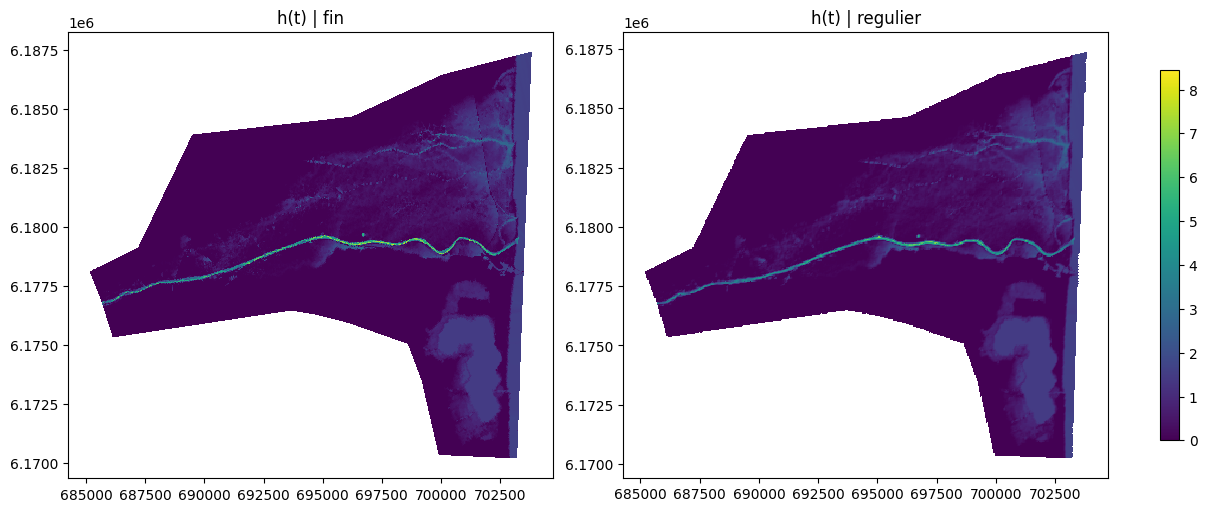

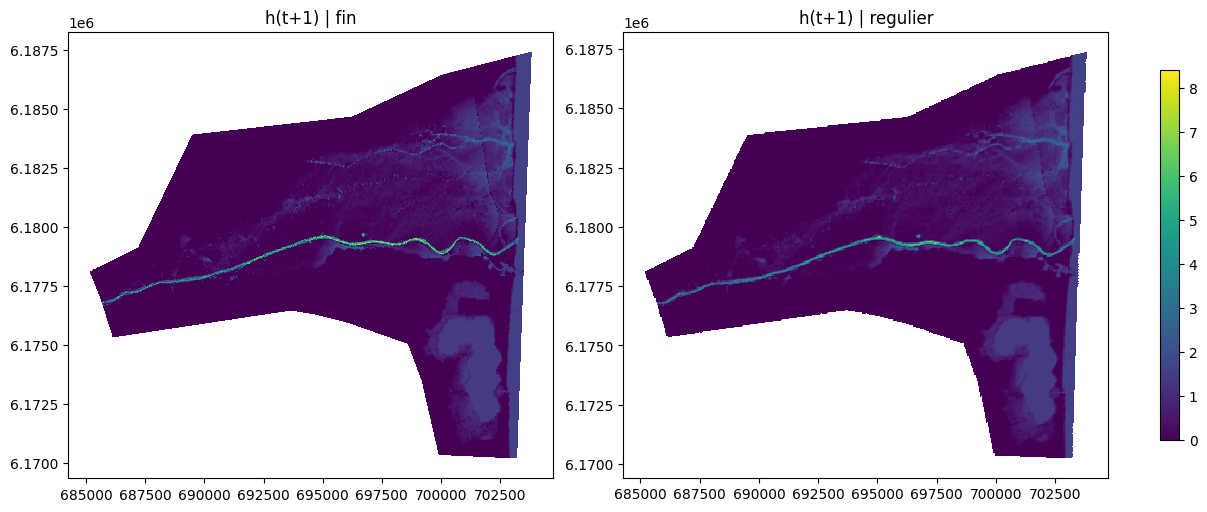

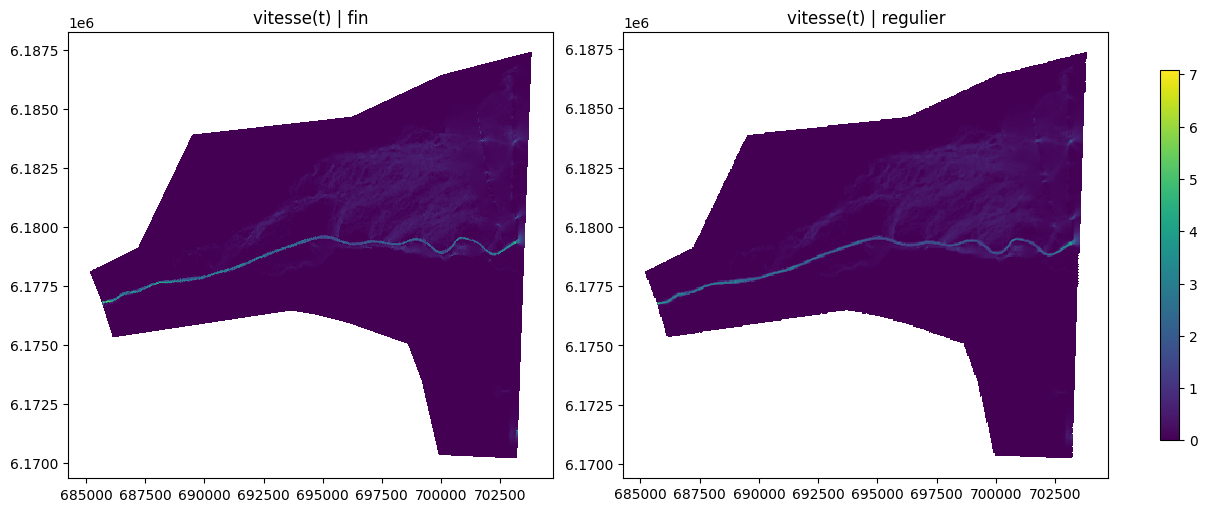

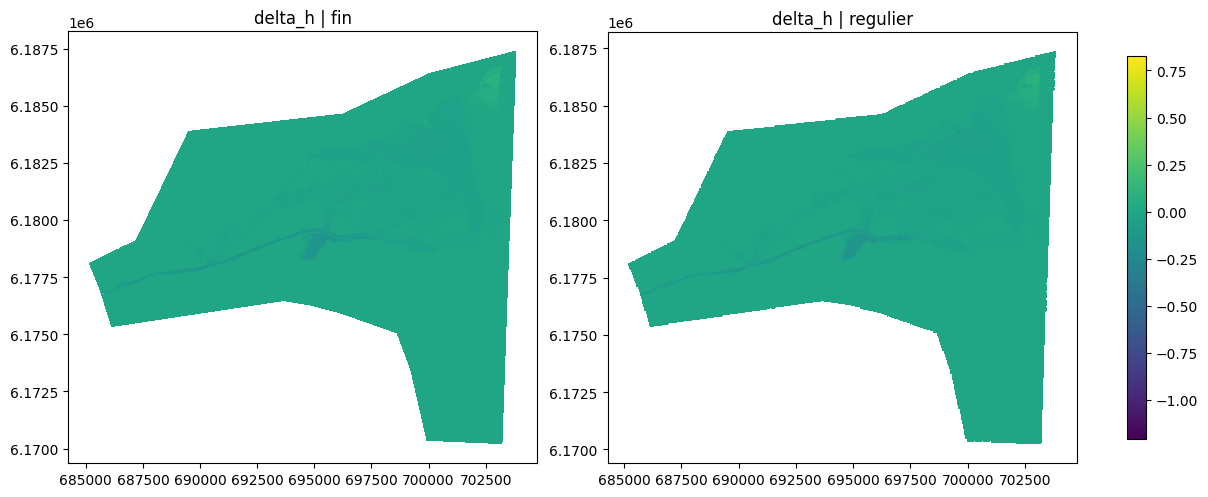

In [8]:
def plot_pair(title, fine_values, regular_values):
    vmin = min(np.nanmin(fine_values), np.nanmin(regular_values))
    vmax = max(np.nanmax(fine_values), np.nanmax(regular_values))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    a0 = axes[0].tripcolor(fine_tri, fine_values, cmap="viridis", vmin=vmin, vmax=vmax)
    a1 = axes[1].tripcolor(regular_tri, regular_values, cmap="viridis", vmin=vmin, vmax=vmax)

    axes[0].set_title(f"{title} | fin")
    axes[1].set_title(f"{title} | regulier")

    for ax in axes:
        ax.set_aspect("equal")

    fig.colorbar(a1, ax=axes, shrink=0.8)
    plt.show()
    
plot_pair("h(t)", x_fine[:, 0], x_reg[:, 0])

plot_pair("h(t+1)", x_fine[:, 0] + y_fine[:, 0], x_reg[:, 0] + y_reg[:, 0])

plot_pair(
    "vitesse(t)",
    np.sqrt(x_fine[:, 1]**2 + x_fine[:, 2]**2),
    np.sqrt(x_reg[:, 1]**2 + x_reg[:, 2]**2),
)

plot_pair("delta_h", y_fine[:, 0], y_reg[:, 0])

In [2]:
from pathlib import Path
import pickle
import shutil

INPUT_DIR = Path("/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m")
INPUT_BASE_BIN = INPUT_DIR / "regular_50_dataset_base.bin"
OUTPUT_DIR = INPUT_DIR.parent / "dataset_50m_short"
PKL_GLOB = "regular_50_dataset_*.pkl"

START = 35
STOP = 65  

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(INPUT_BASE_BIN, OUTPUT_DIR / INPUT_BASE_BIN.name)

def build_output_name(path):
    name = path.name.replace("_0_0-80", f"_0_{START}-{STOP - 1}")
    if name == path.name:
        name = f"{path.stem}_{START}-{STOP - 1}{path.suffix}"
    return name

for pkl_path in sorted(INPUT_DIR.glob(PKL_GLOB)):
    with open(pkl_path, "rb") as f:
        samples = pickle.load(f)

    if len(samples) < STOP:
        raise ValueError(f"{pkl_path.name}: {len(samples)} samples, il en faut au moins {STOP}")

    reduced_samples = samples[START:STOP]
    output_path = OUTPUT_DIR / build_output_name(pkl_path)

    with open(output_path, "wb") as f:
        pickle.dump(reduced_samples, f)

    print(f"{pkl_path.name} -> {output_path.name} | {len(samples)} -> {len(reduced_samples)} samples")

print("done:", OUTPUT_DIR)

regular_50_dataset_G1_P1000_0_0-80.pkl -> regular_50_dataset_G1_P1000_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P1200_0_0-80.pkl -> regular_50_dataset_G1_P1200_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P1400_0_0-80.pkl -> regular_50_dataset_G1_P1400_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P1600_0_0-80.pkl -> regular_50_dataset_G1_P1600_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P1800_0_0-80.pkl -> regular_50_dataset_G1_P1800_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P2000_0_0-80.pkl -> regular_50_dataset_G1_P2000_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P2200_0_0-80.pkl -> regular_50_dataset_G1_P2200_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P2400_0_0-80.pkl -> regular_50_dataset_G1_P2400_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P2600_0_0-80.pkl -> regular_50_dataset_G1_P2600_0_35-64.pkl | 80 -> 30 samples
regular_50_dataset_G1_P2800_0_0-80.pkl -> regular_50_dataset_G1_P2800_0_35-64.pkl | 80 -> 3

In [16]:
base_graph = dgl.load_graphs("/work/m24046/m24046mrcr/dataset_x8_avec_ts/full/Group_4_peak_3600_Group_4_peak_3600_base.bin")[0][0]
print(base_graph)
node_type = np.asarray(base_graph.ndata["static"][:, :4], dtype=np.float32)

row_sums = node_type.sum(axis=1)
is_binary = np.isin(node_type, [0.0, 1.0]).all(axis=1)
has_one_hot_sum = np.isclose(row_sums, 1.0)
is_one_hot = is_binary & has_one_hot_sum

print("nodes:", len(node_type))
print("all one-hot:", bool(is_one_hot.all()))
print("non one-hot count:", int((~is_one_hot).sum()))
print("type counts:", node_type.argmax(axis=1).astype(int).tolist()[:10], "...")
print("counts by class:", np.bincount(node_type.argmax(axis=1), minlength=4))

if not is_one_hot.all():
    bad_idx = np.where(~is_one_hot)[0][:10]
    print("bad indices:", bad_idx)
    print("bad rows:")
    print(node_type[bad_idx])

Graph(num_nodes=412844, num_edges=2464330,
      ndata_schemes={'static': Scheme(shape=(6,), dtype=torch.float32)}
      edata_schemes={'x': Scheme(shape=(3,), dtype=torch.float32)})
nodes: 412844
all one-hot: True
non one-hot count: 0
type counts: [3, 3, 3, 3, 3, 0, 3, 3, 3, 0] ...
counts by class: [406480   1589     17   4758]
